<a href="https://colab.research.google.com/github/sujithaindrakanti-sketch/SCT_DS_3/blob/main/task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Purchase Prediction using Decision Tree Classifier

## Problem Statement

The objective of this project is to build a Decision Tree Classification model that predicts whether a customer will subscribe to a bank term deposit based on their demographic and behavioral information.

The dataset contains information collected from direct marketing campaigns conducted by a Portuguese banking institution. The bank contacted customers through phone calls to determine whether they would purchase the offered product (term deposit) or not.

The target variable is `y`, where:
- Yes → Customer subscribed to the term deposit
- No → Customer did not subscribe

This is a binary classification problem.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
df = pd.read_csv("/content/bank-additional-full.csv" , sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.shape

(41188, 21)

## Dataset Overview

The dataset contains 41,188 customer records and 21 columns.

There are:
- 20 independent variables (customer demographic and behavioral features)
- 1 dependent variable (`y`) which indicates whether the customer subscribed to the term deposit.

The features include customer information such as age, job, education, loans, previous interactions, and economic indicators.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Initial Data Observations

- The dataset contains both numerical and categorical variables.
- Numerical features include age, duration, campaign count, and economic indicators.
- Categorical features include job, marital status, education, and contact type.
- No missing values are present in the dataset.
- Some categorical values are represented as "unknown", which indicates unavailable information.

## Data Cleaning

Data cleaning is an important step to improve data quality before applying machine learning algorithms.

The dataset contains both numerical and categorical variables. We inspect the dataset for missing values, duplicate records, and inconsistent values.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Dataset Structure

The dataset contains:

- 41,188 customer records
- 21 columns
- 20 independent features
- 1 target variable (`y`)

The dataset consists of:
- Numerical features such as age, duration, campaign, and economic indicators.
- Categorical features such as job, education, marital status, and communication type.

The target variable `y` represents whether the customer subscribed to the bank term deposit.

In [6]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


### Insight:

The dataset does not contain any missing values. Therefore, no missing value imputation is required.

In [7]:
df.duplicated().sum()

np.int64(12)

In [8]:
df = df.drop_duplicates()

### Duplicate Record Analysis

Duplicate records were checked to avoid repeated customer information influencing the model.

If duplicate rows were present, they were removed before further analysis.

In [9]:
# Numerical columns

numerical_features = df.select_dtypes(include=['int64','float64']).columns

numerical_features

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [10]:
# Categorical columns

categorical_features = df.select_dtypes(include=['object']).columns

categorical_features

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

### Feature Type Analysis

The dataset contains:

- 10 numerical features
- 11 categorical features

Since decision tree algorithms require numerical input, categorical variables need to be converted into numerical form before model training.

In [11]:
for col in df.select_dtypes(include='object'):
    print(col, df[col].value_counts().get('unknown',0))

job 330
marital 80
education 1730
default 8596
housing 990
loan 990
contact 0
month 0
day_of_week 0
poutcome 0
y 0


### Unknown Value Analysis

Some categorical columns contain an "unknown" category.

Examples:

- Job: 330 unknown values
- Education: 1730 unknown values
- Default: 8596 unknown values
- Housing: 990 unknown values
- Loan: 990 unknown values

These values do not represent missing data. They indicate that the information was unavailable during the marketing campaign.

Removing these records would reduce the dataset size significantly, therefore unknown values are retained as a separate category.

In [12]:
df = df.replace("unknown","Unknown")

In [13]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,258.315815,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,259.305321,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


### Numerical Feature Summary

The statistical summary shows:

- Customer age ranges from 17 to 98 years.
- The average customer age is around 40 years.
- Most customers were contacted a small number of times during the campaign.
- The `pdays` feature contains the value 999, which represents customers who were not previously contacted.
- Economic indicators represent the market conditions during the campaign period.

## Data Cleaning Summary

The dataset was inspected before model development.

- The dataset contains 41,188 customer records and 21 columns.
- No missing values were detected.
- Duplicate records were checked.
- Numerical and categorical attributes were identified.
- Categorical features containing "unknown" values were retained because they represent unavailable information rather than invalid records.
- The dataset was verified using descriptive statistics.

After cleaning, the dataset was considered suitable for exploratory analysis and model training.

# Exploratory Data Analysis (EDA)

## Target Variable Analysis

The target variable `y` represents whether a customer subscribed to the bank term deposit.

- Yes → Customer purchased the product
- No → Customer did not purchase the product

Analyzing the distribution helps us understand the balance of the classes.

In [14]:
df['y'].value_counts()

,count
y,
no,36537
yes,4639


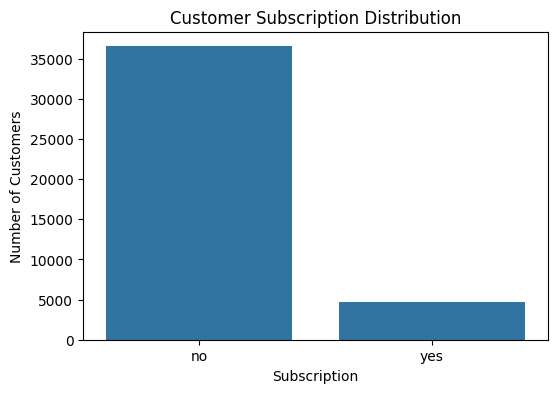

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='y',
    data=df
)

plt.title("Customer Subscription Distribution")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

plt.show()

### Insight:

The dataset contains a higher number of customers who did not subscribe to the term deposit compared to customers who subscribed.

This indicates that the dataset is imbalanced, meaning the model may have more examples of the "No" class during training.

# Age Distribution

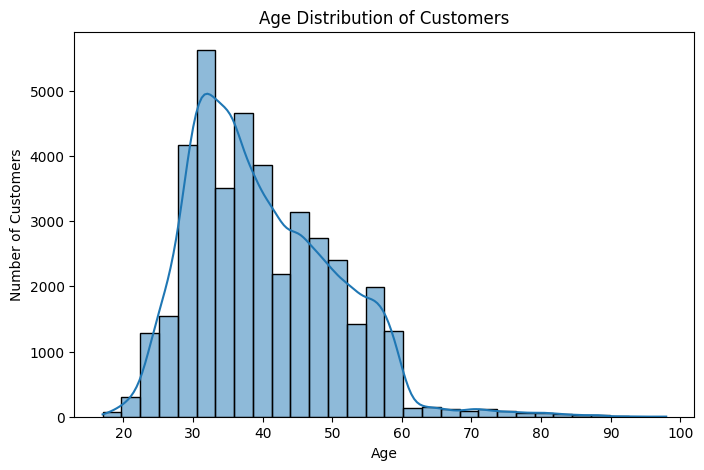

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

# Job vs Subscription

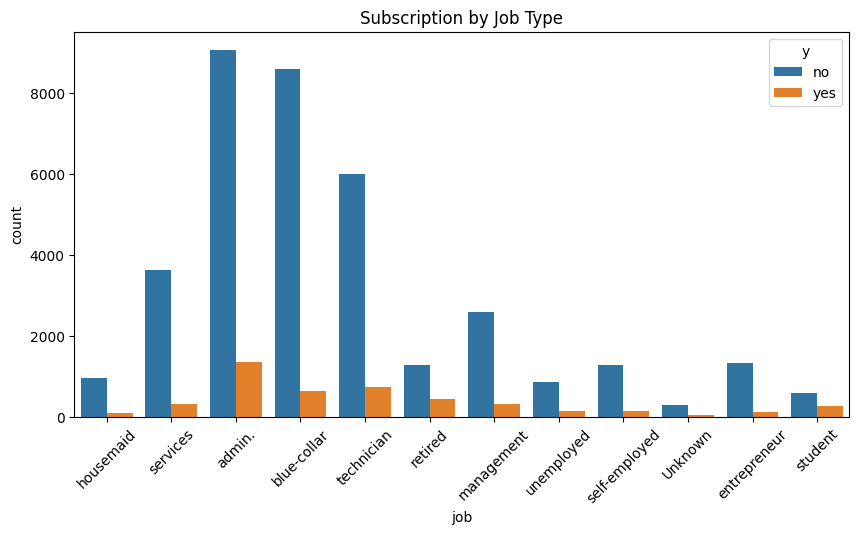

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='job',
    hue='y',
    data=df
)

plt.xticks(rotation=45)

plt.title("Subscription by Job Type")

plt.show()

# Education vs Subscription

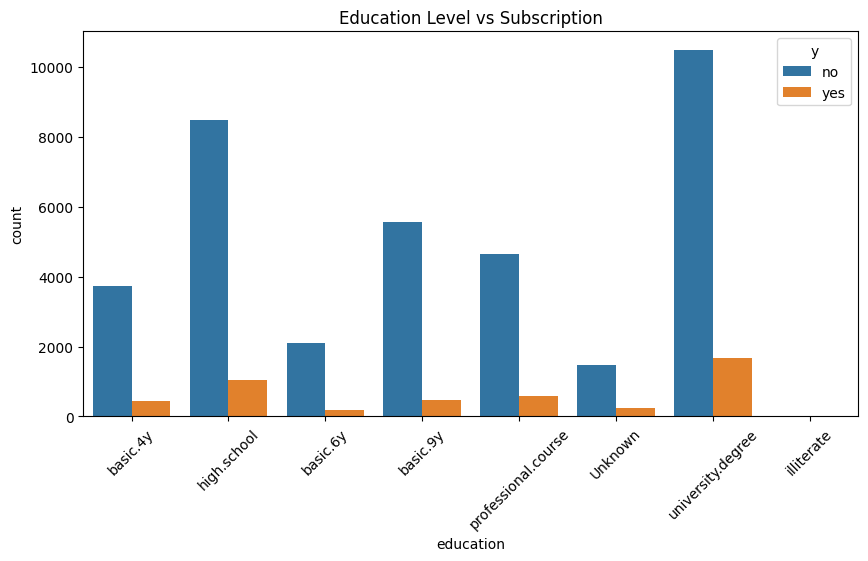

In [18]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='education',
    hue='y'
)

plt.xticks(rotation=45)

plt.title("Education Level vs Subscription")

plt.show()

### Insight

Customers with different education levels show different subscription patterns.

Education may affect financial awareness and interest in investment products.

# Call Duration vs Subscription

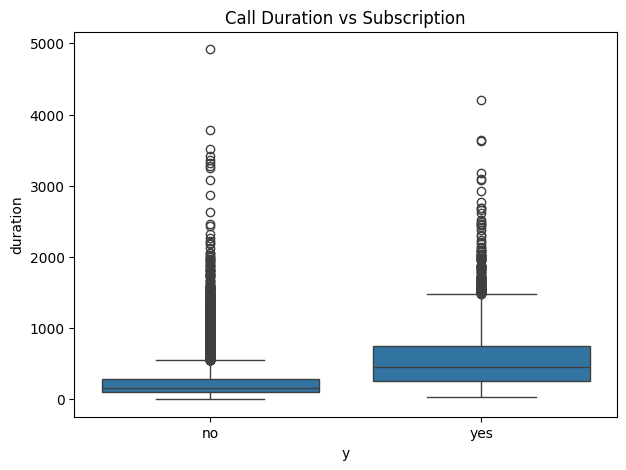

In [19]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='y',
    y='duration'
)

plt.title("Call Duration vs Subscription")

plt.show()

### Insight

Customers who subscribed generally had longer call durations.

This suggests that higher customer engagement during the conversation increases the likelihood of subscription.

# Previous Campaign Outcome

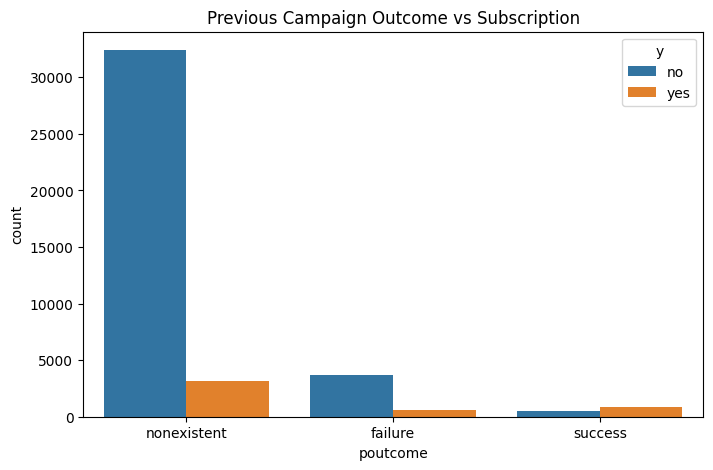

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='poutcome',
    hue='y'
)

plt.title("Previous Campaign Outcome vs Subscription")

plt.show()

### Insight

Customers with successful outcomes from previous campaigns have a higher chance of subscribing.

Previous interaction history is an important factor for predicting customer behavior.

# Correlation Heatmap

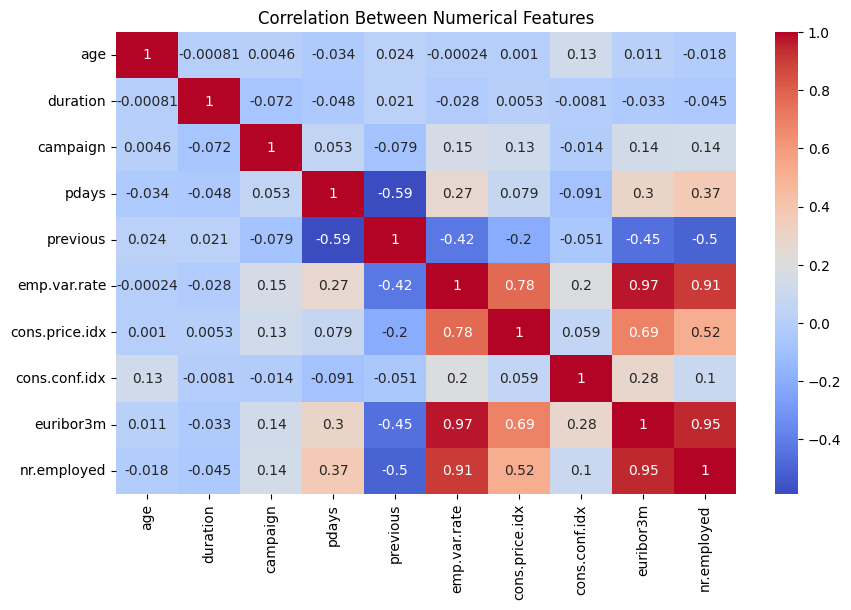

In [21]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Numerical Features")

plt.show()

### Insight

The correlation analysis shows relationships among numerical variables.

Economic features show stronger relationships because they represent the overall market conditions during the campaign period.

## EDA Summary

From exploratory analysis:

- The dataset is imbalanced, with more non-subscribers than subscribers.
- Customer demographics such as age, job, and education influence subscription behavior.
- Call duration appears to be an important indicator of customer interest.
- Previous campaign success increases the probability of subscription.
- Both customer information and campaign history contribute to prediction.

These findings help in selecting and training the Decision Tree classification model.

# Data Preprocessing

Machine learning algorithms cannot directly process categorical text values.
Therefore, preprocessing is performed to convert the data into a numerical format suitable for model training.

The preprocessing steps include:

- Separating features and target variable
- Encoding categorical variables
- Splitting data into training and testing sets

In [22]:
# Separating independent and dependent variables

X = df.drop('y', axis=1)

y = df['y']

## Feature and Target Separation

The dataset is divided into:

- X → Independent variables (customer demographic and behavioral information)
- y → Dependent variable (customer subscription decision)

The model will learn patterns from X to predict y.

In [23]:
y = y.map({
    'no':0,
    'yes':1
})

In [24]:
y.value_counts()

,count
y,
0,36537
1,4639


## Target Encoding

The target variable was converted into binary format:

0 represents customers who did not subscribe.

1 represents customers who subscribed.

This allows the classification algorithm to perform mathematical operations.

In [25]:
X.select_dtypes(include='object').columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

In [26]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [27]:
X.shape

(41176, 53)

## Categorical Encoding

One-hot encoding was applied to categorical variables.

This converts text-based categories into numerical values without creating an artificial ranking between categories.

The `drop_first=True` option removes one category from each feature to avoid redundant information.

# Train-Test Split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
print(X_train.shape)
print(X_test.shape)

(32940, 53)
(8236, 53)


## Train-Test Split

The dataset was divided into:

- 80% training data
- 20% testing data

The training data is used to build the model, while the testing data evaluates how well the model performs on unseen customer records.

The `stratify` parameter is used to maintain the same class distribution in both training and testing sets.

## Preprocessed Dataset Shape

After applying one-hot encoding, the number of input features increased from 20 to 53 because categorical variables were transformed into numerical representations.

The dataset was divided into:

- Training set: 32,940 records (80%)
- Testing set: 8,236 records (20%)

The training set will be used to build the Decision Tree model, while the testing set will be used for evaluation.

# Decision Tree Classifier

A Decision Tree is a supervised machine learning algorithm used for classification tasks.

The model learns decision rules from customer demographic and behavioral information and predicts whether a customer will subscribe to the bank term deposit.

The tree splits the data based on the most important features and continues making decisions until it reaches a final prediction.

In [30]:
from sklearn.tree import DecisionTreeClassifier

# Final Decision Tree Model


dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_split=10,
    random_state=42
)
dt_model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=10,
                       random_state=42)

## Model Training

The Decision Tree model was trained using the training dataset.

The entropy criterion is used to measure the information gain while splitting nodes.

A split with higher information gain is preferred because it creates better separation between customers who subscribe and those who do not.

In [31]:
y_pred = dt_model.predict(X_test)

In [32]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9133074307916464


## Accuracy Analysis

The model achieved good accuracy on the test dataset.

However, accuracy alone is not enough because the dataset is imbalanced, with more non-subscribers than subscribers.

Therefore, additional evaluation metrics are required.

In [33]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7308
           1       0.65      0.51      0.57       928

    accuracy                           0.91      8236
   macro avg       0.79      0.74      0.76      8236
weighted avg       0.91      0.91      0.91      8236



## Classification Metrics

Precision:
Measures how many predicted subscriptions were actually correct.

Recall:
Measures how many actual subscribers were successfully identified.

F1-score:
Balances precision and recall.

These metrics provide better understanding of model performance.

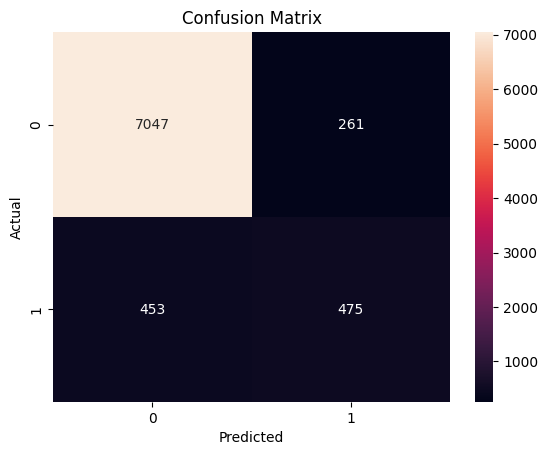

In [34]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Confusion Matrix Analysis

The confusion matrix shows:

- True Negatives: Customers correctly predicted as not subscribing
- True Positives: Customers correctly predicted as subscribing
- False Positives: Customers predicted as subscribers but did not subscribe
- False Negatives: Customers who subscribed but were missed by the model

This helps evaluate the types of prediction errors made by the model.

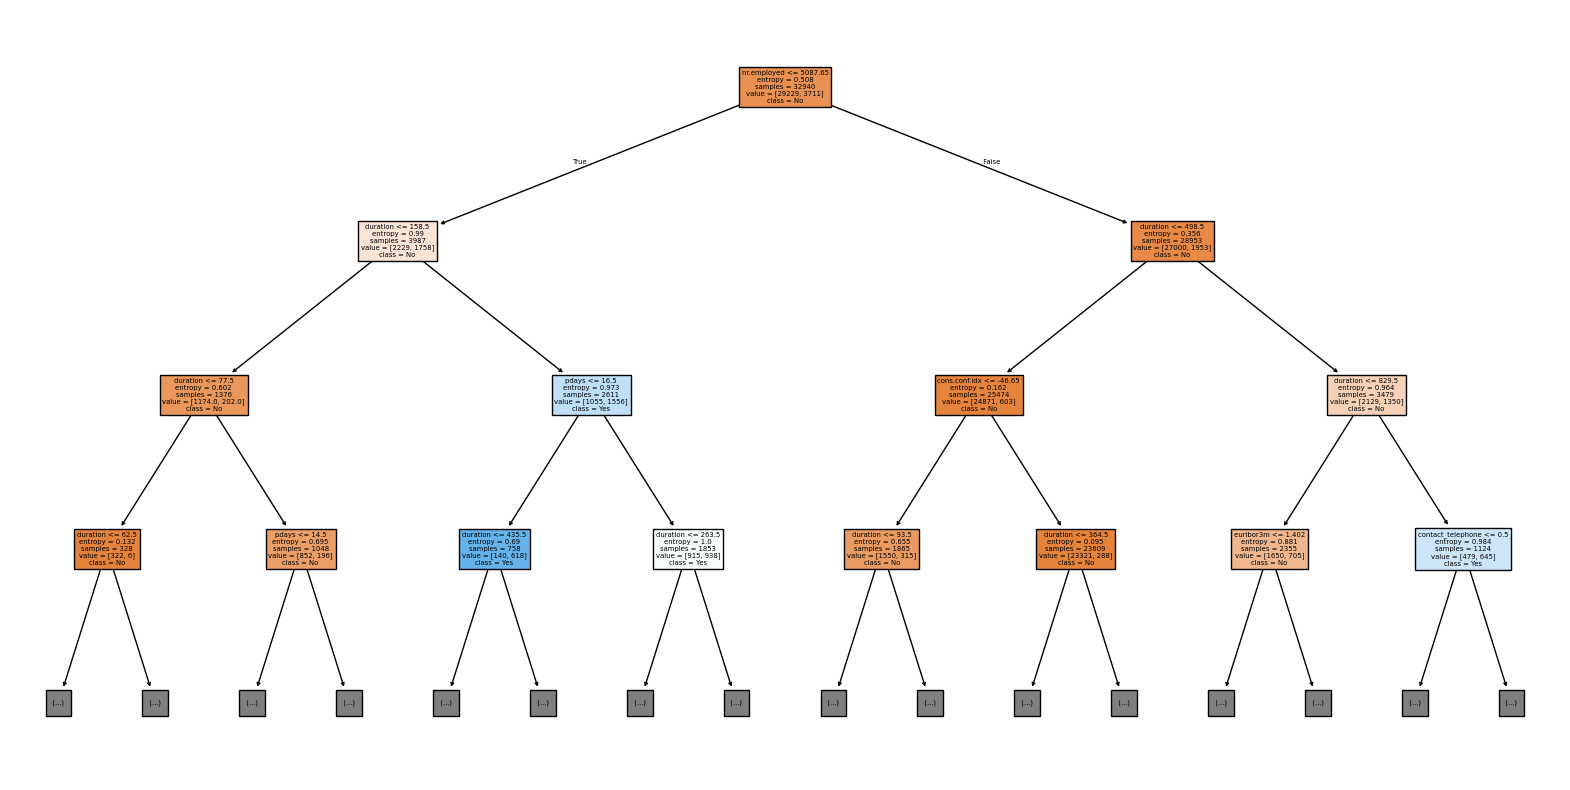

In [35]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    max_depth=3,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True
)

plt.show()

## Decision Tree Visualization

The visualization shows how the model makes decisions.

The tree selects important features at each split and creates rules to classify customers.

Features closer to the root generally have greater influence on predictions.

In [36]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
1,duration,0.525576
9,nr.employed,0.313736
7,cons.conf.idx,0.082772
3,pdays,0.025466
5,emp.var.rate,0.021479
8,euribor3m,0.019032
6,cons.price.idx,0.007064
47,day_of_week_mon,0.001296
37,contact_telephone,0.001239
2,campaign,0.000869


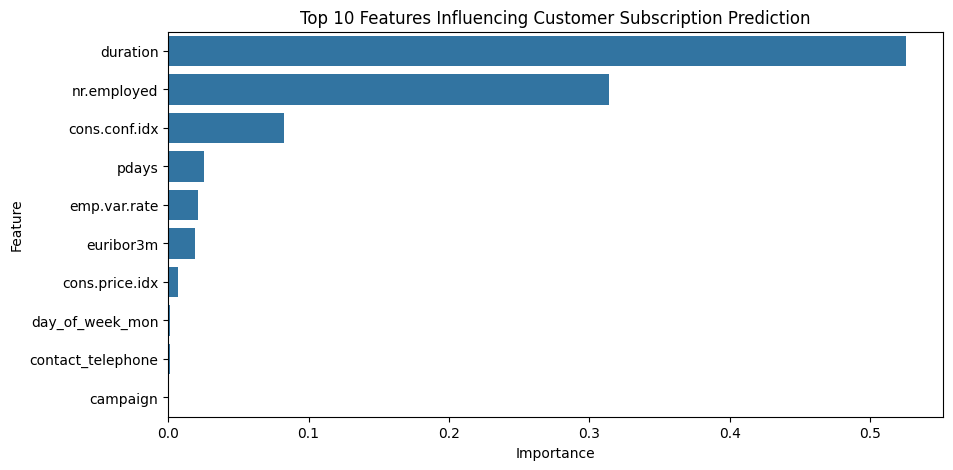

In [43]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Features Influencing Customer Subscription Prediction")Z

plt.show()

## Feature Importance Analysis

The model identifies the most influential features for predicting customer subscription.

Features related to customer interaction history and campaign behavior generally have higher importance because they directly reflect customer engagement.

In [38]:
print("Training Accuracy:", accuracy_score(y_train, dt_model.predict(X_train)))
print("Testing Accuracy:", accuracy_score(y_test, dt_model.predict(X_test)))

Training Accuracy: 0.9158166363084396
Testing Accuracy: 0.9133074307916464


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, dt_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7308
           1       0.65      0.51      0.57       928

    accuracy                           0.91      8236
   macro avg       0.79      0.74      0.76      8236
weighted avg       0.91      0.91      0.91      8236



## Model Selection

The final Decision Tree model was selected after evaluating model performance.

The tuned Decision Tree without class weighting provided a better balance between accuracy, precision, and recall, making it suitable for predicting customer subscription behavior.

In [40]:
import joblib

joblib.dump(
    dt_model,
    "bank_subscription_decision_tree.pkl"
)

['bank_subscription_decision_tree.pkl']

## Final Model Performance

The final Decision Tree classifier achieved:

Training Accuracy: 91.58%

Testing Accuracy: 91.33%

The small difference between training and testing accuracy shows that the model generalizes well and avoids major overfitting.

Evaluation Metrics:

- Accuracy: 91%
- Precision (Subscribed): 65%
- Recall (Subscribed): 51%
- F1-score (Subscribed): 57%

## Key Findings

From the analysis and model results:

1. Customer interaction duration was the most important factor influencing subscription prediction.

2. Economic indicators such as employment rate and interest rate affected customer decisions.

3. Previous campaign history contributed to predicting customer behavior.

4. The Decision Tree model successfully learned patterns from customer demographic and behavioral data.

5. The model can assist banks in identifying customers who are more likely to subscribe to a term deposit.